In [10]:
import xarray as xr
import rioxarray
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from scipy.ndimage import median_filter, minimum_filter, maximum_filter, uniform_filter
import lightgbm as lgb 
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import joblib

# Load input data and trained model

In [11]:
def compute_a(y):
    return y.sum() / len(y)

def compute_ahat(yhat, y_vals, yhat_vals):
    area_proportion_1 = yhat.sum() / len(yhat)
    area_proportion_0 = 1 - area_proportion_1
    
    # Figure out precision/false-omission-rate as the weighted-mean
    cms = [confusion_matrix(y_val, yhat_val, labels=[True, False]) for y_val, yhat_val in zip(y_vals, yhat_vals)] # (tp, fn), (fp, tn)
    tps = [e[0][0] for e in cms]
    fns = [e[0][1] for e in cms]
    tns = [e[1][1] for e in cms]
    fps = [e[1][0] for e in cms]

    # Figure out weighted-averaged TN, ...
    n_vals = np.array([len(e) for e in y_vals])
    tp = np.mean(tps)
    fn = np.mean(fns)
    fp = np.mean(fps)
    tn = np.mean(tns)

    # Compute validation set's metrics
    false_omission_rate = fn / (fn + tn)
    precision = tp / (tp + fp)

    # Compute adjusted unbiased area proportion
    ahat = (area_proportion_1 * precision) + (area_proportion_0 * false_omission_rate)

    # Compute Confidence Interval (Olofsson Variance)
    n_cocoa = tp + fp
    n_non_cocoa = fn + tn

    # Variance contribution from both strata
    var_cocoa = (area_proportion_1 ** 2) * (precision * (1 - precision)) / (n_cocoa - 1)
    var_non_cocoa = (area_proportion_0 ** 2) * (false_omission_rate * (1 - false_omission_rate)) / (n_non_cocoa - 1)
    
    # Standard Error
    se = np.sqrt(var_cocoa + var_non_cocoa)
    
    # Margin of Error for 95% Confidence Interval (Z-score = 1.96)
    margin_of_error = 1.96 * se
    
    ci_lower = max(0.0, ahat - margin_of_error) # Clamp at 0%
    ci_upper = min(1.0, ahat + margin_of_error) # Clamp at 100%

    return ahat, (ci_lower, ci_upper)

In [12]:
import numpy as np
import pandas as pd
from skimage.exposure import match_histograms

def apply_histogram_matching(X_input, X_ref, cols):
    """
    Applies histogram matching to specific columns of a dataframe.
    Maps the distribution of X_input to match the reference distribution of X_ref.
    """
    # Create a copy to prevent SettingWithCopyWarning and preserve original data
    X_matched = X_input.copy()
    X_ref_clean = X_ref.copy()
    
    # 1. Clean Infinities and NaNs in both datasets for the target columns
    X_matched[cols] = X_matched[cols].replace([np.inf, -np.inf], np.nan)
    X_ref_clean[cols] = X_ref_clean[cols].replace([np.inf, -np.inf], np.nan)
    
    X_matched[cols] = X_matched[cols].fillna(X_matched[cols].median())
    X_ref_clean[cols] = X_ref_clean[cols].fillna(X_ref_clean[cols].median())
    
    # 2. Apply Histogram Matching band-by-band
    for col in cols:
        matched_array = match_histograms(
            image=X_matched[col].values, 
            reference=X_ref_clean[col].values
        )
        X_matched[col] = matched_array
        
    return X_matched

In [13]:
def predict(region: str, year: int):
    # Load model payload
    payload = joblib.load(f'trained-{region.lower()}-2021.joblib')

    clf = payload['clf']
    user_attrs = payload['user_attrs']
    X_train = payload['X_train']
    X_test = payload['X_test']
    X_ref = pd.concat([X_train, X_test])
    
    # Load input data
    df = pd.read_parquet(f"../data/silver/ghana-{year}-df.parquet")

    # Extract features
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl', "region"]
    features += ['tci', 'ndvi', 'evi', 'evi2', 'ndre_b5', 'ndre_b6', 'ndre_b7', 'gndvi', 'ndwi']
    features += ['valid_observations']
    features += ['cloud_confidence']
    features += [e for e in df.columns if any(k in e for k in ['3x3', '5x5', '11x11'])]
    
    # Filter for the target region
    region_mask = df.region.apply(lambda x: x.lower()) == region.lower()
    lonlat_df = df.loc[region_mask, ['lon', 'lat']]
    X = df.loc[region_mask, features]
    X = X.drop(columns=['region'])

    # Histogram-matching off X
    categorical_cols = ['scl', 'cloud_confidence', 'valid_observations']
    continuous_cols = [col for col in X.columns if col not in categorical_cols]
    X = apply_histogram_matching(X_input=X, X_ref=X_ref, cols=continuous_cols)

    yhat = clf.predict(X)

    return yhat, X, lonlat_df, user_attrs["y_vals"], user_attrs["yhat_vals"]

predict('ashanti', 2021);

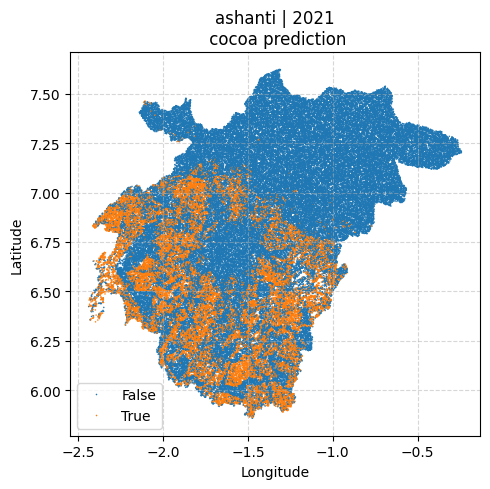

In [14]:
# Predict ashanti
region = 'ashanti'
year = 2021
yhat, X, lonlat_df, y_vals, yhat_vals = predict(region, year)

# Plot the folds
plt.figure(figsize=(5, 5))
sns.scatterplot(data=lonlat_df, x='lon', y='lat', hue=yhat, s=1, alpha=1, edgecolor=None)

plt.title(f'{region} | {year}\n cocoa prediction')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

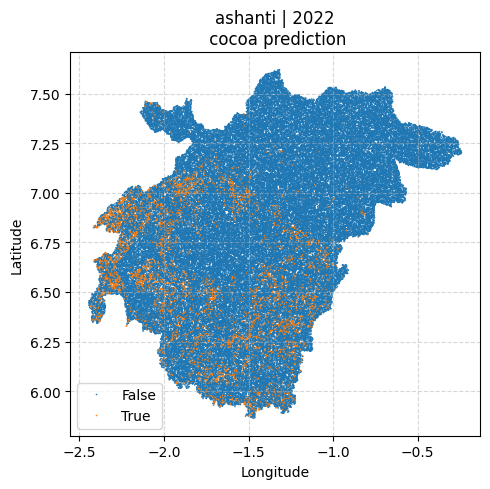

In [15]:
# Predict ashanti
region = 'ashanti'
year = 2022
yhat, X, lonlat_df, y_vals, yhat_vals = predict(region, year)

# Plot the folds
plt.figure(figsize=(5, 5))
sns.scatterplot(data=lonlat_df, x='lon', y='lat', hue=yhat, s=1, alpha=1, edgecolor=None)

plt.title(f'{region} | {year}\n cocoa prediction')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# Real area from Cocoa area estimation

My issue is that I'm dealing with 2 back-to-back area estimation.
Hence, for each region, I have

1. The real cocoa area
2. The ETHZ's cocoa area estimation
3. My cocoa area estimation

First, I need to figure out how to estimate the real cocoa area from the ETHZ's cocoa area estimation.

## Our estimate

The ETHZ's estimated area are the best we'll get.
We make the assumption that the ETHZ's estimate is correct, i.e

$$Â^{corrected}_{ETHZ} = A_{true}$$

From them, we'll compare our estimate, i.e.

$$A_{true} = Â^{corrected}_{ETHZ} = A_{LGBM} * \frac{Precision^{Val}_{LGBM}}{Recall^{Val}_{LGBM}}$$
$$\rightarrow Â^{corrected}_{LGBM} = A_{LGBM} * \frac{Precision^{Val}_{LGBM}}{Recall^{Val}_{LGBM}}$$

We'll measure how far off $Â^{corrected}_{ETHZ}$ we are

In [16]:
def compute_corrected_area_proportion(y, precision, recall):
    area_proportion = y.sum() / len(y)
    return area_proportion * precision / recall

In [17]:
def print_our_corrected_area_proportion(region: str, year: int) -> float:
    """Print the Corrected Area Proportion (CAP) of our prediction with a Bootstrapped Confidence Interval."""
    # Get the prediction matrix and metrics
    yhat, _, _, y_vals, yhat_vals = predict(region, year)

    ahat, (ci_lower, ci_upper) = compute_ahat(yhat, y_vals, yhat_vals)

    # Format the output bounds
    ap_str = f"{ahat*100:.2f}% [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]"

    print(f"{region.title()}'s entire region ({year}): Our cocoa area proportion (corrected): {ap_str}")

In [21]:
print_our_corrected_area_proportion('ashanti', 2021)
print_our_corrected_area_proportion('western north', 2021)
print_our_corrected_area_proportion('western', 2021)
print_our_corrected_area_proportion('ahafo', 2021)
print_our_corrected_area_proportion('central', 2021)
print_our_corrected_area_proportion('eastern', 2021)

Ashanti's entire region (2021): Our cocoa area proportion (corrected): 26.11% [24.93%, 27.28%]
Western North's entire region (2021): Our cocoa area proportion (corrected): 49.70% [47.15%, 52.26%]
Western's entire region (2021): Our cocoa area proportion (corrected): 42.14% [39.87%, 44.41%]
Ahafo's entire region (2021): Our cocoa area proportion (corrected): 41.02% [38.13%, 43.91%]
Central's entire region (2021): Our cocoa area proportion (corrected): 36.14% [33.68%, 38.60%]
Eastern's entire region (2021): Our cocoa area proportion (corrected): 13.22% [12.03%, 14.40%]


In [20]:
print_our_corrected_area_proportion('ashanti', 2022)
print_our_corrected_area_proportion('western north', 2022)
print_our_corrected_area_proportion('western', 2022)
print_our_corrected_area_proportion('ahafo', 2022)
print_our_corrected_area_proportion('central', 2022)
print_our_corrected_area_proportion('eastern', 2022)

Ashanti's entire region (2022): Our cocoa area proportion (corrected): 11.62% [10.55%, 12.69%]
Western North's entire region (2022): Our cocoa area proportion (corrected): 47.26% [44.72%, 49.80%]
Western's entire region (2022): Our cocoa area proportion (corrected): 40.29% [38.03%, 42.54%]
Ahafo's entire region (2022): Our cocoa area proportion (corrected): 35.18% [32.33%, 38.04%]
Central's entire region (2022): Our cocoa area proportion (corrected): 30.30% [27.90%, 32.70%]
Eastern's entire region (2022): Our cocoa area proportion (corrected): 6.68% [5.62%, 7.75%]
